# Análise Exploratória de Dados — Santa Catarina (SC)

## 1. Apresentação da Base e Objetivos
Este estudo analisa os dados de votação por seção eleitoral no estado de Santa Catarina (SC) nas eleições de 2022 (`detalhe_votacao_secao_2022_SC.csv`). O objetivo é identificar padrões de engajamento eleitoral, analisar o comportamento do eleitor catarinense e verificar a qualidade dos dados.

### Perguntas de Negócio a serem respondidas:
1. Como a taxa de abstenção varia entre os municípios de Santa Catarina e qual a relação com o tamanho das seções?
2. Quais municípios de SC apresentam as maiores proporções de votos brancos e nulos?
3. Existe relação direta entre a taxa de abstenção e a proporção de votos brancos/nulos em SC?
4. O comportamento do eleitor em SC segue o mesmo padrão identificado no Estado do Rio de Janeiro e Minas Gerais?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


In [4]:
# 1. Carregar a base de dados de Santa Catarina
df_sc = pd.read_csv("../dados/detalhe_votacao_secao_2022_SC.csv", encoding="latin1", sep=";")

# 2. Filtrar as colunas essenciais do projeto
colunas = [
    "NM_MUNICIPIO", "NR_ZONA", "NR_SECAO", "QT_APTOS",
    "QT_COMPARECIMENTO", "QT_ABSTENCOES", "QT_VOTOS_BRANCOS",
    "QT_VOTOS_NULOS", "QT_VOTOS_NOMINAIS", "QT_VOTOS_LEGENDA",
    "NR_TURNO", "CD_CARGO"
]
df_sc = df_sc[colunas].copy()
df_sc["estado"] = "SC"

# Exibe as primeiras 5 linhas da tabela de SC
df_sc.head()

,NM_MUNICIPIO,NR_ZONA,NR_SECAO,QT_APTOS,QT_COMPARECIMENTO,QT_ABSTENCOES,QT_VOTOS_BRANCOS,QT_VOTOS_NULOS,QT_VOTOS_NOMINAIS,QT_VOTOS_LEGENDA,NR_TURNO,CD_CARGO,estado
0,SÃO JOÃO DO SUL,54,26,331,300,31,8,3,289,0,2,3,SC
1,XANXERÊ,43,54,270,212,58,14,7,177,14,1,6,SC
2,XANXERÊ,43,54,270,212,58,21,24,167,0,1,5,SC
3,XANXERÊ,43,54,270,212,58,14,6,174,18,1,7,SC
4,XANXERÊ,43,54,269,217,52,2,3,212,0,2,3,SC


In [5]:
# Criando as colunas derivadas de proporções e taxas para Santa Catarina
df_sc["taxa_abstencao"] = df_sc["QT_ABSTENCOES"] / df_sc["QT_APTOS"]
df_sc["prop_brancos"] = df_sc["QT_VOTOS_BRANCOS"] / df_sc["QT_APTOS"]
df_sc["prop_nulos"] = df_sc["QT_VOTOS_NULOS"] / df_sc["QT_APTOS"]
df_sc["QT_VOTOS_VALIDOS"] = df_sc["QT_VOTOS_NOMINAIS"] + df_sc["QT_VOTOS_LEGENDA"]
df_sc["prop_validos"] = df_sc["QT_VOTOS_VALIDOS"] / df_sc["QT_APTOS"]

# Exibe as métricas calculadas para as primeiras linhas
df_sc[["NM_MUNICIPIO", "taxa_abstencao", "prop_brancos", "prop_nulos", "prop_validos"]].head()

,NM_MUNICIPIO,taxa_abstencao,prop_brancos,prop_nulos,prop_validos
0,SÃO JOÃO DO SUL,0.093656,0.024169,0.009063,0.873112
1,XANXERÊ,0.214815,0.051852,0.025926,0.707407
2,XANXERÊ,0.214815,0.077778,0.088889,0.618519
3,XANXERÊ,0.214815,0.051852,0.022222,0.711111
4,XANXERÊ,0.193309,0.007435,0.011152,0.788104


In [6]:
# Contar quantidade de seções únicas por município em SC
secoes_por_municipio_sc = (
    df_sc.groupby("NM_MUNICIPIO")["NR_SECAO"]
         .nunique()
         .sort_values(ascending=False)
)

# Identificar top 5 maiores e top 5 menores
top5_sc = secoes_por_municipio_sc.head(5).index.tolist()
bottom5_sc = secoes_por_municipio_sc.tail(5).index.tolist()
municipios_10_sc = top5_sc + bottom5_sc

# Filtrar o DataFrame apenas para esses 10 municípios
df_sc_10 = df_sc[df_sc["NM_MUNICIPIO"].isin(municipios_10_sc)].copy()

print("5 Maiores municípios de SC (em seções):", top5_sc)
print("5 Menores municípios de SC (em seções):", bottom5_sc)

5 Maiores municípios de SC (em seções): ['JOINVILLE', 'FLORIANÓPOLIS', 'BLUMENAU', 'ITAJAÍ', 'SÃO JOSÉ']
5 Menores municípios de SC (em seções): ['SANTA TEREZINHA DO PROGRESSO', 'BARRA BONITA', 'MACIEIRA', 'CUNHATAÍ', 'SÃO MIGUEL DA BOA VISTA']


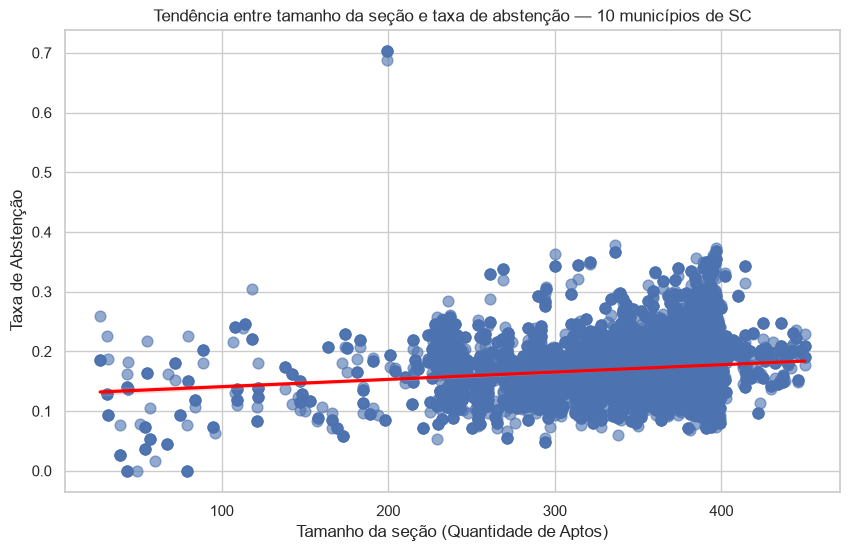

Correlação entre tamanho da seção e abstenção em SC: 0.1456


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de dispersão com linha de tendência para SC
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_sc_10,
    x="QT_APTOS",
    y="taxa_abstencao",
    scatter_kws={"s": 60, "alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Tendência entre tamanho da seção e taxa de abstenção — 10 municípios de SC")
plt.xlabel("Tamanho da seção (Quantidade de Aptos)")
plt.ylabel("Taxa de Abstenção")
plt.show()

# Cálculo da correlação linear
correlacao_sc = df_sc_10["QT_APTOS"].corr(df_sc_10["taxa_abstencao"])
print(f"Correlação entre tamanho da seção e abstenção em SC: {correlacao_sc:.4f}")